### Parallel workflows in LanGraph

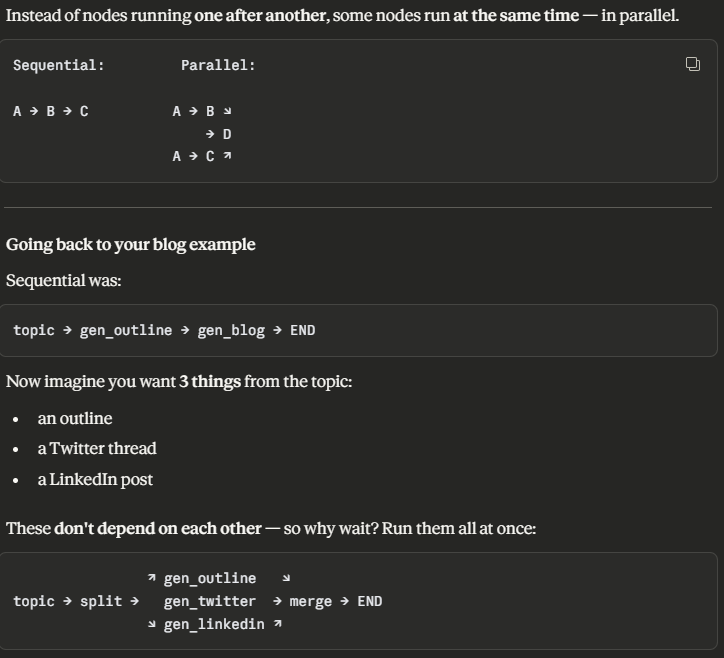

#### What we will do

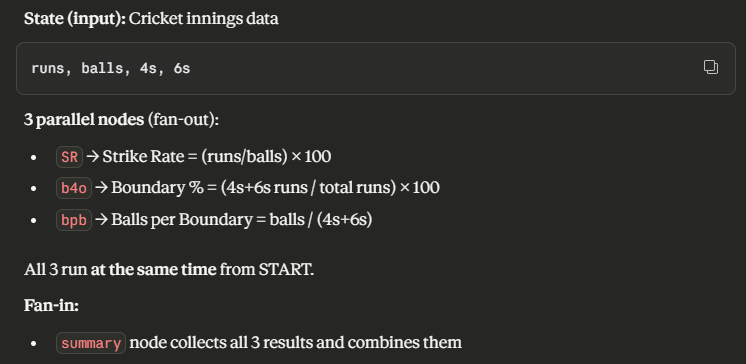

In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

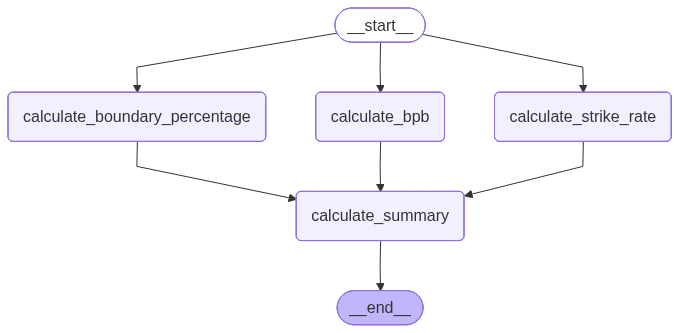

In [ ]:
# Define the state structure for the batsman
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    sr: float
    boundary_percent: float
    bpb: float
    summary: str

# step - 1 : define the graph
graph = StateGraph(BatsmanState)

# define the functions for each node
def calculate_strike_rate(state: BatsmanState) -> BatsmanState: 
    state['sr'] = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'sr': state['sr']} # return only the updated part of the state in parallel workflows

def calculate_boundary_percentage(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['sixes']
    state['boundary_percent'] = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0
    return {'boundary_percent': state['boundary_percent']}

def calculate_bpb(state: BatsmanState) -> BatsmanState:
    state['bpb'] = state['runs'] / state['balls'] if state['balls'] > 0 else 0
    return {'bpb': state['bpb']}

def calculate_summary(state: BatsmanState) -> BatsmanState:
    summary = f"Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}, SR: {state['sr']:.2f}, Boundary%: {state['boundary_percent']:.2f}%, BPB: {state['bpb']:.2f}"
    state['summary'] = summary
    return state

# step - 2 : add nodes
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("calculate_bpb", calculate_bpb)
graph.add_node("calculate_summary", calculate_summary)

# step - 3 : add edges
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_percentage")
graph.add_edge(START, "calculate_bpb")

graph.add_edge("calculate_strike_rate", "calculate_summary")
graph.add_edge("calculate_boundary_percentage", "calculate_summary")
graph.add_edge("calculate_bpb", "calculate_summary")
graph.add_edge("calculate_summary", END)

# step - 4 : compile the graph
workflow = graph.compile()

# step - 5 : visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
# step - 6 : invoke the graph with an initial state
initial_state = {
    "runs": 85,
    "balls": 60,
    "fours": 8,
    "sixes": 3,
}

workflow.invoke(initial_state)

{'runs': 85,
 'balls': 60,
 'fours': 8,
 'sixes': 3,
 'sr': 141.66666666666669,
 'boundary_percent': 18.333333333333332,
 'bpb': 1.4166666666666667,
 'summary': 'Runs: 85, Balls: 60, Fours: 8, Sixes: 3, SR: 141.67, Boundary%: 18.33%, BPB: 1.42'}

### Practicing Parallel workflows with LLM's

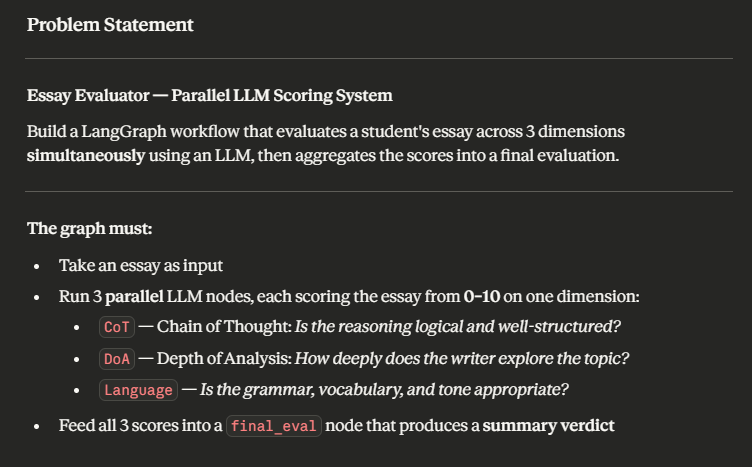

We will learn :
1. Parallel workflows
2. Structured outputs
3. Reducer functions

In [ ]:
#### structured outputs in LLMs ####

from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

# initialize the model
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=1.0,  
    max_tokens=None,
    timeout=None 
)

# define the output structure
class EssayScore(BaseModel):
    score: int          # must be a number
    reasoning: str      # must be a string

# create a structured LLM that outputs in the defined format
structured_llm = model.with_structured_output(EssayScore)

# define a prompt
result = structured_llm.invoke("Review: The movie was absolutely brilliant!")
print(result.score)      # Access the score
print(result.reasoning)   # Access the reasoning

10
The review uses strong positive language ('absolutely brilliant!') indicating extreme satisfaction with the movie, warranting a perfect score.


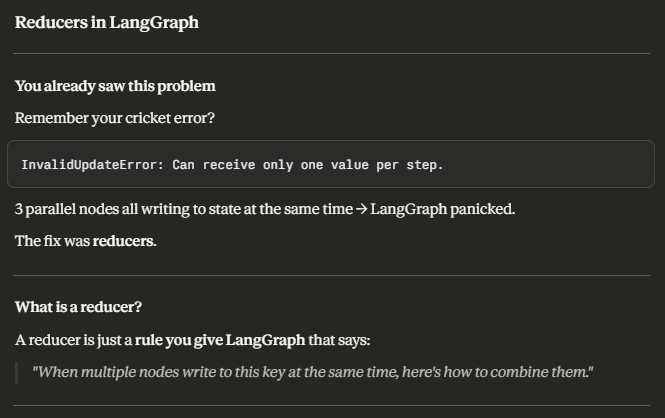

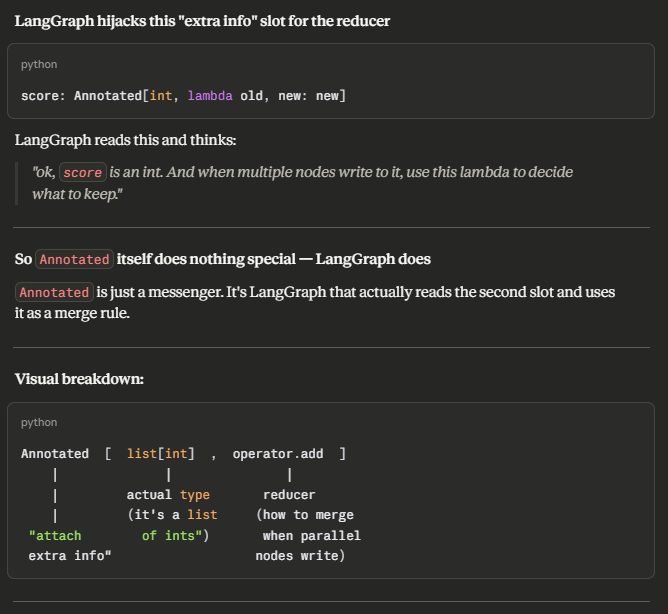

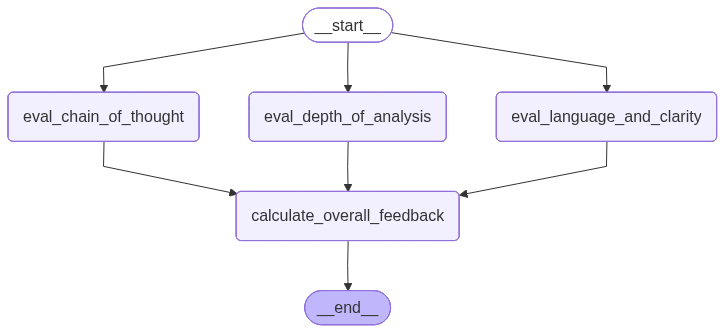

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator
from pydantic import BaseModel
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from dotenv import load_dotenv

load_dotenv()

################################################################
# Defining the Model and Output Structure for Essay Evaluation
################################################################
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    temperature=1.0,  
    max_tokens=None,
    timeout=None 
)

class EssayEvaluationSchema(BaseModel):
    feedback: str
    score: int

structured_llm = model.with_structured_output(EssayEvaluationSchema)

#################################################################
# Defining the State Graph for Essay Evaluation Workflow
#################################################################

class EvaluateEssayState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]  # This will be used to collect scores from parallel nodes


# define the graph
graph = StateGraph(EvaluateEssayState)

# define the functions for each node
def eval_chain_of_thought(state: EvaluateEssayState) -> EvaluateEssayState:
    prompt = f"Evaluate the chain of thought in the essay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "language_feedback": result.feedback,
        "individual_scores": [result.score]  # list with one item, reducer collects it
    }

def eval_depth_of_analysis(state: EvaluateEssayState) -> EvaluateEssayState:
    prompt = f"Evaluate the depth of analysis in the essay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "analysis_feedback": result.feedback,
        "individual_scores": [result.score]  # list with one item, reducer collects it
    }

def eval_language_and_clarity(state: EvaluateEssayState) -> EvaluateEssayState:
    prompt = f"Evaluate the language and clarity in the essay: {state['essay']}"
    result = structured_llm.invoke(prompt)
    return {
        "clarity_feedback": result.feedback,
        "individual_scores": [result.score]  # list with one item, reducer collects it
    }

def calculate_overall_feedback(state: EvaluateEssayState) -> EvaluateEssayState:
    prompt = f"Based on the following feedback, provide an overall evaluation and score for the essay:\n\nChain of Thought Feedback: {state['language_feedback']}\nDepth of Analysis Feedback: {state['analysis_feedback']}\nLanguage and Clarity Feedback: {state['clarity_feedback']}"
    result = structured_llm.invoke(prompt)
    return {
        "overall_feedback": result.feedback
    }

# define the nodes for evaluating the essay
graph.add_node("eval_chain_of_thought", eval_chain_of_thought)
graph.add_node("eval_depth_of_analysis", eval_depth_of_analysis)
graph.add_node("eval_language_and_clarity", eval_language_and_clarity)
graph.add_node("calculate_overall_feedback", calculate_overall_feedback)

# step - 2 : add edges to define the workflow
graph.add_edge(START, "eval_chain_of_thought")
graph.add_edge(START, "eval_depth_of_analysis")
graph.add_edge(START, "eval_language_and_clarity")

graph.add_edge("eval_chain_of_thought", "calculate_overall_feedback")
graph.add_edge("eval_depth_of_analysis", "calculate_overall_feedback")
graph.add_edge("eval_language_and_clarity", "calculate_overall_feedback")
graph.add_edge("calculate_overall_feedback", END)

# step - 3 : compile the graph
workflow = graph.compile()

# step - 4 : visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
# Test the workflow with an example essay

essay = f"The movie explores the complexities of human emotions through a compelling narrative and strong character development. The cinematography is stunning, and the performances are top-notch. However, the pacing is a bit slow in the middle, which may affect viewer engagement."
initial_state = {
    "essay": essay
}

workflow.invoke(initial_state)

{'essay': 'The movie explores the complexities of human emotions through a compelling narrative and strong character development. The cinematography is stunning, and the performances are top-notch. However, the pacing is a bit slow in the middle, which may affect viewer engagement.',
 'language_feedback': 'The chain of thought is well-structured and balanced. It effectively moves from general praise for thematic depth and narrative to specific commendations for cinematography and performances, before introducing a nuanced critique regarding pacing and its potential impact on viewer engagement. This logical progression creates a comprehensive mini-evaluation.',
 'analysis_feedback': "The analysis offers a good high-level overview of the movie's strengths and weaknesses, touching on narrative, character development, cinematography, performances, and pacing. However, it lacks depth and specific examples to support its claims. For instance, it states 'complexities of human emotions' but do